In [22]:
import xarray as xr
import matplotlib.pyplot as plt
# from metpy.plots import ctables
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
import cmweather as cmw
import cmasher as cmr
import numpy as np
import numpy.ma as ma
import os
from pathlib import Path

from scipy.constants import dyn
from zarr.codecs.numcodecs import Blosc
import dask
from dask.diagnostics import ProgressBar

import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='zarr')

In [2]:
def create_file_list(analysis_dir, sf, ef):
    analysis_dir = Path(analysis_dir)
    all_files = sorted(analysis_dir.glob('derived_vars_000*.zarr'))

    if not all_files:
        raise RuntimeError(f'No zarr files in {analysis_dir}')

    selected_files = []
    for f in all_files:
        try:
            num = int(f.stem.split('_')[-1])
        except ValueError:
            continue
        if sf <= num <= ef:
            selected_files.append(f)

    if not selected_files:
        raise RuntimeError(f'No files found in range {sf}–{ef}')

    return selected_files


def get_cold_pool(cp):
    return cp.where(cp <= -0.01)

In [3]:
def pad_to_target_grid(da, target_y, target_x):

    y = da['yh'].values
    x = da['xh'].values

    dy = np.round(y[1]-y[0], 2)
    dx = np.round(x[1]-x[0], 2)

    ty = np.array([dy*j for j in range(target_y)])
    tx = np.array([dx*i for i in range(target_x)])

    full = np.full((target_y, target_x), 0, dtype=da.dtype)
    full[0:da.sizes['yh'], 0:da.sizes['xh']] = da.values
    full[np.isnan(full)]=0

    padded = xr.DataArray(
        full,
        coords={'y_rel': ty, 'x_rel': tx},
        dims=('y_rel', 'x_rel'),
        attrs=da.attrs,
        name=da.name,
    )
    return padded

In [4]:
def write_zarr(ds_out, outdir, outfile):

    outdir.mkdir(parents=True, exist_ok=True)
    outpath = f'{outdir}/{outfile}'

    delayed = ds_out.to_zarr(
        outpath,
        mode='w',
        zarr_version=3,
        consolidated=False,
    )

    with ProgressBar():
        dask.compute(delayed)

    return

In [5]:
exp_dir = '/storm/topping/cold_pools/runs/2500_core'
# exp_dir = '/storm/topping/cold_pools/runs/1500_core'
# exp_dir = '/storm/topping/cold_pools/runs/3500_core'

# exp_dir = '/storm/topping/cold_pools/runs/moderateCAPE/set1'
# exp_dir = '/storm/topping/cold_pools/runs/moderateCAPE/set2'
# exp_dir = '/storm/topping/cold_pools/runs/moderateCAPE/set3'
# exp_dir = '/storm/topping/cold_pools/runs/moderateCAPE/set4'

# exp_dir = '/storm/topping/cold_pools/runs/highCAPE/set1'
# exp_dir = '/storm/topping/cold_pools/runs/highCAPE/set2'
# exp_dir = '/storm/topping/cold_pools/runs/highCAPE/set3'
# exp_dir = '/storm/topping/cold_pools/runs/highCAPE/set4'

# exp_dir = '/storm/topping/cold_pools/runs/lowCAPE/set1'
# exp_dir = '/storm/topping/cold_pools/runs/lowCAPE/set2'

# exp_dir = '/storm/topping/cold_pools/runs/nssl3'
# exp_dir = '/storm/topping/cold_pools/runs/morrison'

# exp_dir = '/storm/topping/cold_pools/runs/sigtor'

# exp_dir = '/storm/topping/cold_pools/runs/freeslip'

# exp_dir = '/storm/topping/cold_pools/runs/random_pert/set1'
# exp_dir = '/storm/topping/cold_pools/runs/random_pert/set2'
# exp_dir = '/storm/topping/cold_pools/runs/random_pert/set3'
# exp_dir = '/storm/topping/cold_pools/runs/random_pert/set4'
# exp_dir = '/storm/topping/cold_pools/runs/random_pert/set5'

exp_dir = Path(exp_dir)
outdir = exp_dir / 'var_comps'
print(f'Experiment directory: {exp_dir}')

Experiment directory: /storm/topping/cold_pools/runs/2500_core


In [30]:
st = 90  # start time
et = 180  # end time

ft = 45  # first time after initialization
ff = 2  # number of first file after initialization
dt = 1  # large timestep (minutes)
i1 = int((st - ft) / dt)
i2 = int((et - ft) / dt)
sf = i1 + ff
ef = i2 + ff

regimes = ['mm', 'md', 'dm', 'dd']
regime_dict = {}

for regime in regimes:
    sim_name = str(exp_dir / regime).replace('/storm/topping/cold_pools/runs/', '').replace('/', '-')
    print(f'\n{sim_name}:')

    analysis_dir = exp_dir / regime / 'derived_vars'

    file_list = create_file_list(analysis_dir, sf, ef)

    regime_dict[regime] = {}

    refl_ts = []
    uh_ts = []
    b_ts = []
    cp_ts = []
    depth_ts = []

    for i, f in enumerate(file_list):
        print(f'\t- Processing {f}...')

        ds = xr.open_zarr(
            f,
            zarr_format=3,
            consolidated=False,
            decode_timedelta=False
        )

        refl = pad_to_target_grid(ds['dbz'].isel(time=0, zh=0), 301, 401)
        uh = pad_to_target_grid(ds['uh'].isel(time=0), 301, 401)
        b = pad_to_target_grid(ds['b2'].isel(time=0, zh=0), 301, 401)
        cp = pad_to_target_grid(get_cold_pool(ds['cp_clean'].isel(time=0, zh=0)), 301, 401)
        depth = pad_to_target_grid(ds['cp_depth'].isel(time=0)*1000, 301, 401)

        refl_ts.append(refl)
        uh_ts.append(uh)
        b_ts.append(b)
        cp_ts.append(cp)
        depth_ts.append(depth)

        ds.close()

    refl_all = xr.concat(refl_ts, dim='time', join='exact')
    refl_comp = refl_all.median(dim='time')
    regime_dict[regime]['refl'] = refl_comp

    uh_all = xr.concat(uh_ts, dim='time', join='exact')
    uh_comp = uh_all.median(dim='time')
    regime_dict[regime]['uh'] = uh_comp
    
    b_all = xr.concat(b_ts, dim='time', join='exact')
    b_comp = b_all.median(dim='time')
    regime_dict[regime]['b'] = b_comp

    cp_all = xr.concat(cp_ts, dim='time', join='exact')
    cp_comp = cp_all.median(dim='time')
    regime_dict[regime]['cp'] = cp_comp

    depth_all = xr.concat(depth_ts, dim='time', join='exact')
    depth_comp = depth_all.median(dim='time')
    regime_dict[regime]['depth'] = depth_comp


for regime, comp_dict in regime_dict.items():
    ds_out = xr.Dataset(
        {
            'refl': comp_dict['refl'],
            'uh': comp_dict['uh'],
            'b': comp_dict['b'],
            'cp': comp_dict['cp'],
            'depth': comp_dict['depth']
        }
    )
    ds_out = ds_out.assign_coords(regime=regime)

    print(f'\tWriting to {outdir}')
    write_zarr(ds_out, outdir, f'{regime}_comp.zarr')


2500_core-mm:
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000047.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000048.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000049.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000050.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000051.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000052.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000053.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000054.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000055.zarr...
	- Processing /storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000056.zar

/tmp/ipykernel_2775332/2849087751.py:6: FutureWarning: zarr_version is deprecated, use zarr_format
  delayed = ds_out.to_zarr(
/home/dtopping/.conda/envs/basic_met/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=2, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


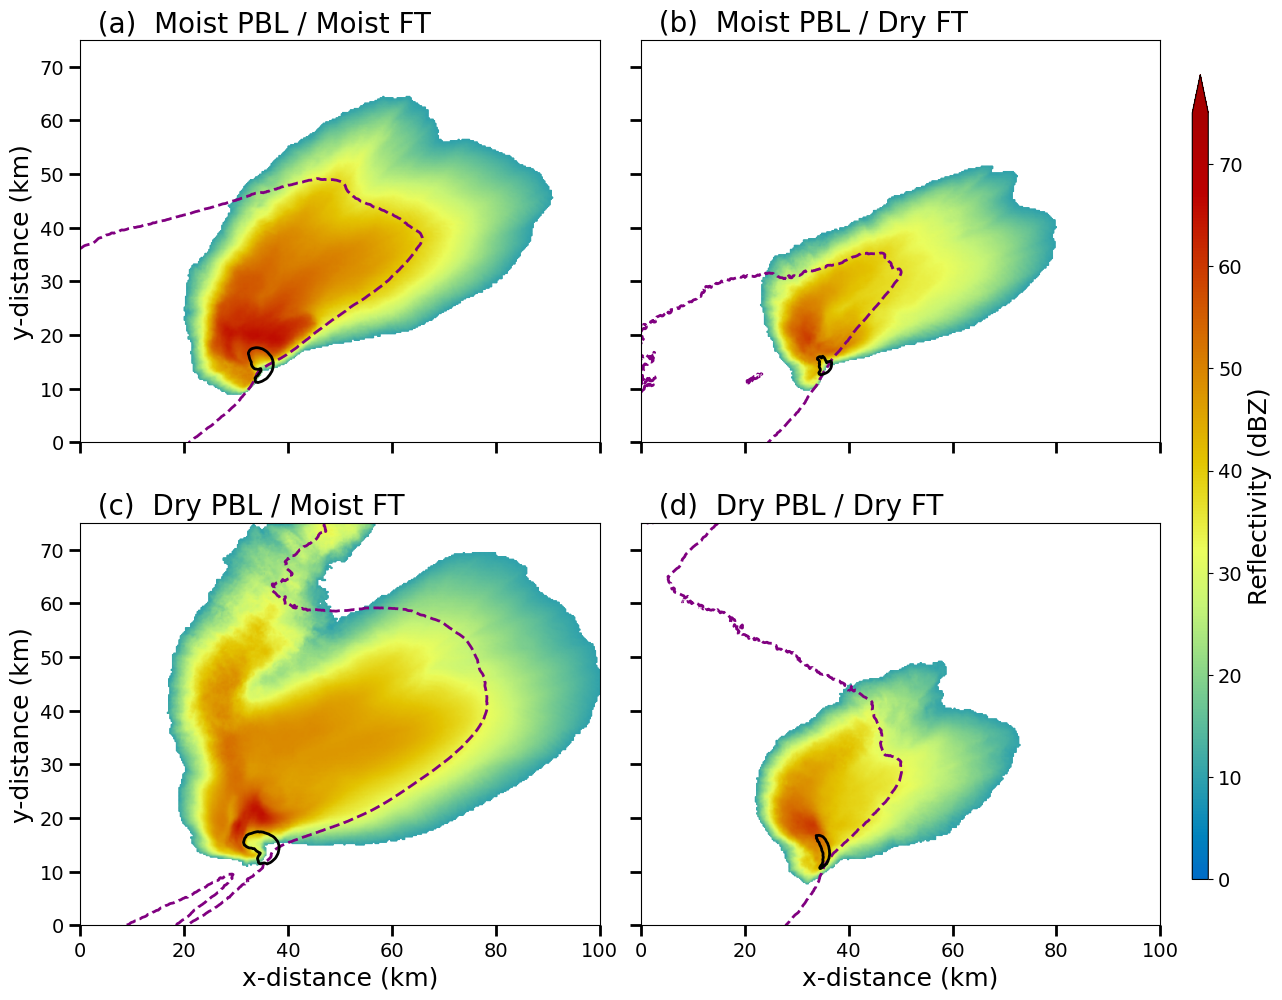

In [31]:
fig,axs = plt.subplots(2,2,figsize=(16,11.5))
axs = axs.flatten()

for regime in regime_dict:

    comp_file = exp_dir / f'var_comps/{regime}_comp.zarr'

    ds = xr.open_zarr(
        comp_file,
        zarr_format=3,
        consolidated=False,
        decode_timedelta=False
    )

    if 'mm' in regime:
        i=0
        title='  (a)  Moist PBL / Moist FT'#-' + HODO + '-' + CAPE
    elif 'md' in regime:
        i=1
        title='  (b)  Moist PBL / Dry FT'#-' + HODO + '-' + CAPE
    elif 'dm' in regime:
        i=2
        title='  (c)  Dry PBL / Moist FT'#-' + HODO + '-' + CAPE
    elif 'dd' in regime:
        i=3
        title='  (d)  Dry PBL / Dry FT'#-' + HODO + '-' + CAPE


    axs[i].set_title(title,fontsize=20,loc='left')

    x = ds.x_rel.values
    y = ds.y_rel.values

    refl = ds['refl'].values
    refl_mask = np.ma.masked_array(refl, refl<=10)
    # norm,cmap = ctables.registry.get_with_range('NWSReflectivity',0,75)
    cmap = 'HomeyerRainbow'
    norm = colors.Normalize(0,75)
    ref_plot = axs[i].pcolormesh(x,y, refl_mask,
                                 shading='gouraud',cmap=cmap,norm=norm,
                                 zorder=0)

    b = ds['b'].values
    axs[i].contour(x,y, b, [-0.01],
                   colors='purple',linestyles='dashed',linewidths=2,
                   zorder=1)

    uh = ds['uh'].values
    axs[i].contour(x,y, uh, [600],
                   colors='k',
                   linewidths=2,zorder=2)

    ds.close()


axs[2].set_xlabel('x-distance (km)', fontsize=18)
axs[3].set_xlabel('x-distance (km)', fontsize=18)
axs[3].tick_params(axis='x', which='major', labelsize=14)

axs[0].set_ylabel('y-distance (km)', fontsize=18)
axs[0].tick_params(axis='y', which='major', labelsize=14)
axs[2].set_ylabel('y-distance (km)', fontsize=18)
axs[2].tick_params(axis='both', which='major', labelsize=14)

axs[0].tick_params(axis='x', which='major', labelcolor='white')
axs[1].tick_params(axis='both', which='major', labelcolor='white')
axs[3].tick_params(axis='y', which='major', labelcolor='white')

axs[0].tick_params(axis='both', which='major', length=8, width=2)
axs[1].tick_params(axis='both', which='major', length=8, width=2)
axs[2].tick_params(axis='both', which='major', length=8, width=2)
axs[3].tick_params(axis='both', which='major', length=8, width=2)


fig.subplots_adjust(right=0.8, hspace=0.26, wspace=0.25)
cbar_ax = fig.add_axes([0.82, 0.15, 0.01, 0.7])
cb = plt.colorbar(ref_plot,cax=cbar_ax, extend='max')
cb.set_label(label='Reflectivity (dBZ)',fontsize=18)
cb.ax.tick_params(labelsize=14)

plt.subplots_adjust(wspace=0.08, hspace=0.2)


outpath = exp_dir / 'ref_comp_NEW.pdf'
plt.savefig(outpath, bbox_inches='tight')
outpath = exp_dir / 'ref_comp_NEW.png'
plt.savefig(outpath, bbox_inches='tight')

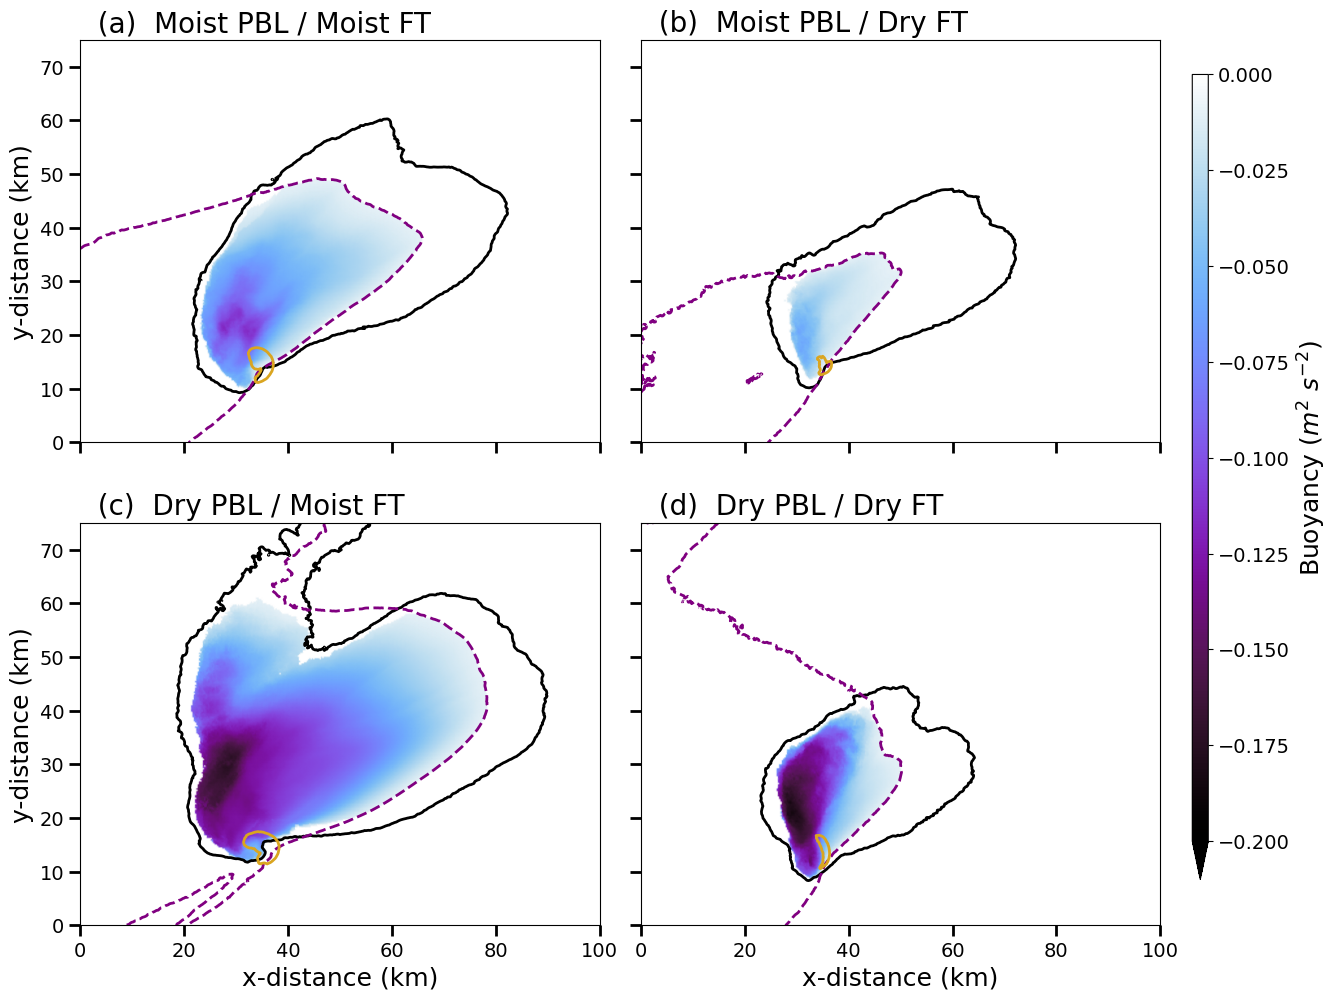

In [32]:
fig,axs = plt.subplots(2,2,figsize=(16,11.5))
axs = axs.flatten()

for regime in regime_dict:

    comp_file = exp_dir / f'var_comps/{regime}_comp.zarr'

    ds = xr.open_zarr(
        comp_file,
        zarr_format=3,
        consolidated=False,
        decode_timedelta=False
    )

    if 'mm' in regime:
        i=0
        title='  (a)  Moist PBL / Moist FT'#-' + HODO + '-' + CAPE
    elif 'md' in regime:
        i=1
        title='  (b)  Moist PBL / Dry FT'#-' + HODO + '-' + CAPE
    elif 'dm' in regime:
        i=2
        title='  (c)  Dry PBL / Moist FT'#-' + HODO + '-' + CAPE
    elif 'dd' in regime:
        i=3
        title='  (d)  Dry PBL / Dry FT'#-' + HODO + '-' + CAPE


    axs[i].set_title(title,fontsize=20,loc='left')

    x = ds.x_rel.values
    y = ds.y_rel.values

    cp = ds['cp'].values
    cmap = cmr.voltage
    norm = colors.Normalize(-0.2,0)
    cp_plot = axs[i].pcolormesh(x,y, cp,
                      shading='gouraud',cmap=cmap,norm=norm,
                      zorder=0)

    refl = ds['refl'].values
    axs[i].contour(x,y, refl, [20],
                   colors='k',linestyles='solid',linewidths=2,
                   zorder=1)

    b = ds['b'].values
    axs[i].contour(x,y, b, [-0.01],
                   colors='purple',linestyles='dashed',linewidths=2,
                   zorder=1)

    uh = ds['uh'].values
    axs[i].contour(x,y, uh, [600],
                   colors='goldenrod',linestyles='solid',linewidths=2,
                   zorder=2)

    ds.close()


axs[2].set_xlabel('x-distance (km)', fontsize=18)
axs[3].set_xlabel('x-distance (km)', fontsize=18)
axs[3].tick_params(axis='x', which='major', labelsize=14)

axs[0].set_ylabel('y-distance (km)', fontsize=18)
axs[0].tick_params(axis='y', which='major', labelsize=14)
axs[2].set_ylabel('y-distance (km)', fontsize=18)
axs[2].tick_params(axis='both', which='major', labelsize=14)

axs[0].tick_params(axis='x', which='major', labelcolor='white')
axs[1].tick_params(axis='both', which='major', labelcolor='white')
axs[3].tick_params(axis='y', which='major', labelcolor='white')

axs[0].tick_params(axis='both', which='major', length=8, width=2)
axs[1].tick_params(axis='both', which='major', length=8, width=2)
axs[2].tick_params(axis='both', which='major', length=8, width=2)
axs[3].tick_params(axis='both', which='major', length=8, width=2)


fig.subplots_adjust(right=0.8, hspace=0.26, wspace=0.25)
cbar_ax = fig.add_axes([0.82, 0.15, 0.01, 0.7])
cb = plt.colorbar(cp_plot,cax=cbar_ax, extend='min')
cb.set_label(label='Buoyancy ($m^{2}$ $s^{-2}$)',fontsize=18)
cb.ax.tick_params(labelsize=14)

plt.subplots_adjust(wspace=0.08, hspace=0.2)


outpath = exp_dir / 'cp_comp_NEW.pdf'
plt.savefig(outpath, bbox_inches='tight')
outpath = exp_dir / 'cp_comp_NEW.png'
plt.savefig(outpath, bbox_inches='tight')

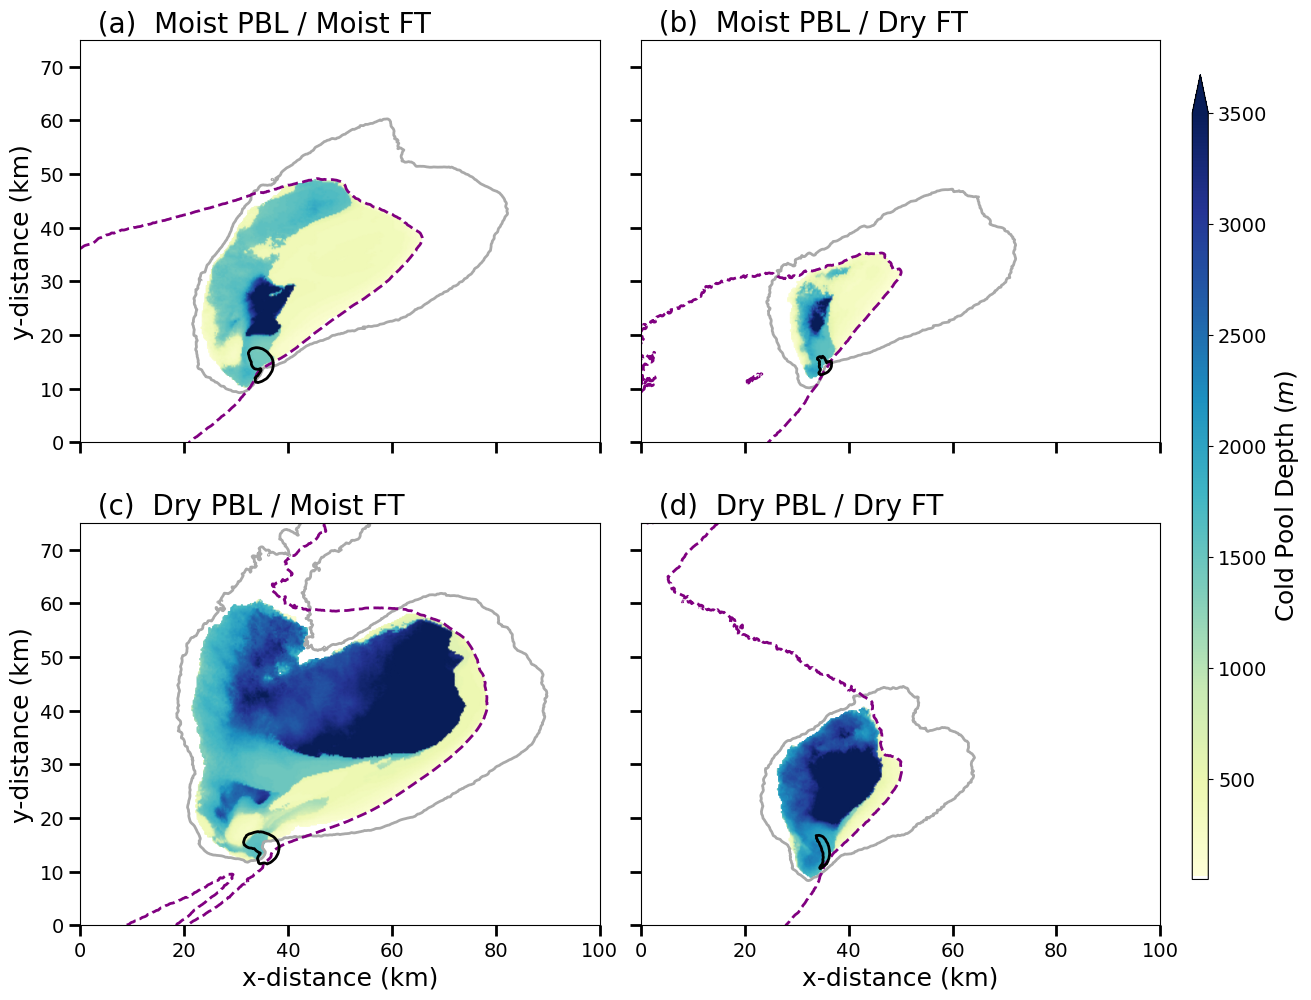

In [33]:
fig,axs = plt.subplots(2,2,figsize=(16,11.5))
axs = axs.flatten()

for regime in regime_dict:

    comp_file = exp_dir / f'var_comps/{regime}_comp.zarr'

    ds = xr.open_zarr(
        comp_file,
        zarr_format=3,
        consolidated=False,
        decode_timedelta=False
    )

    if 'mm' in regime:
        i=0
        title='  (a)  Moist PBL / Moist FT'#-' + HODO + '-' + CAPE
    elif 'md' in regime:
        i=1
        title='  (b)  Moist PBL / Dry FT'#-' + HODO + '-' + CAPE
    elif 'dm' in regime:
        i=2
        title='  (c)  Dry PBL / Moist FT'#-' + HODO + '-' + CAPE
    elif 'dd' in regime:
        i=3
        title='  (d)  Dry PBL / Dry FT'#-' + HODO + '-' + CAPE


    axs[i].set_title(title,fontsize=20,loc='left')

    x = ds.x_rel.values
    y = ds.y_rel.values

    cpd_comp = ds['depth'].values
    cpd_comp_masked = ma.masked_less_equal(cpd_comp, 75)
    norm = colors.Normalize(vmin=50,vmax=3500)
    cmap = plt.cm.YlGnBu
    cmap = cmap.copy()
    cmap.set_bad(color='white')
    cmaplist = [cmap(i) for i in range(cmap.N)]
    cmaplist[0] = (1.0, 1.0, 1.0, 1.0)  # Set the lowest value to white
    custom_cmap = ListedColormap(cmaplist)
    cpd_plot = axs[i].pcolormesh(x,y, cpd_comp_masked,
                                shading='gouraud',cmap=custom_cmap,norm=norm,
                                zorder=0)

    refl = ds['refl'].values
    axs[i].contour(x,y, refl, [20],
                   colors='darkgray',linestyles='solid',linewidths=2,
                   zorder=1)

    b = ds['b'].values
    axs[i].contour(x,y, b, [-0.01],
                   colors='purple',linestyles='dashed',linewidths=2,
                   zorder=1)

    uh = ds['uh'].values
    axs[i].contour(x,y, uh, [600],
                   colors='k',linestyles='solid',linewidths=2,
                   zorder=2)

    ds.close()


axs[2].set_xlabel('x-distance (km)', fontsize=18)
axs[3].set_xlabel('x-distance (km)', fontsize=18)
axs[3].tick_params(axis='x', which='major', labelsize=14)

axs[0].set_ylabel('y-distance (km)', fontsize=18)
axs[0].tick_params(axis='y', which='major', labelsize=14)
axs[2].set_ylabel('y-distance (km)', fontsize=18)
axs[2].tick_params(axis='both', which='major', labelsize=14)

axs[0].tick_params(axis='x', which='major', labelcolor='white')
axs[1].tick_params(axis='both', which='major', labelcolor='white')
axs[3].tick_params(axis='y', which='major', labelcolor='white')

axs[0].tick_params(axis='both', which='major', length=8, width=2)
axs[1].tick_params(axis='both', which='major', length=8, width=2)
axs[2].tick_params(axis='both', which='major', length=8, width=2)
axs[3].tick_params(axis='both', which='major', length=8, width=2)


fig.subplots_adjust(right=0.8, hspace=0.26, wspace=0.25)
cbar_ax = fig.add_axes([0.82, 0.15, 0.01, 0.7])
cb = plt.colorbar(cpd_plot,cax=cbar_ax, extend='max')
cb.set_label(label='Cold Pool Depth ($m$)',fontsize=18)
cb.ax.tick_params(labelsize=14)

plt.subplots_adjust(wspace=0.08, hspace=0.2)


outpath = exp_dir / 'cpd_comp_NEW.pdf'
plt.savefig(outpath, bbox_inches='tight')
outpath = exp_dir / 'cpd_comp_NEW.png'
plt.savefig(outpath, bbox_inches='tight')

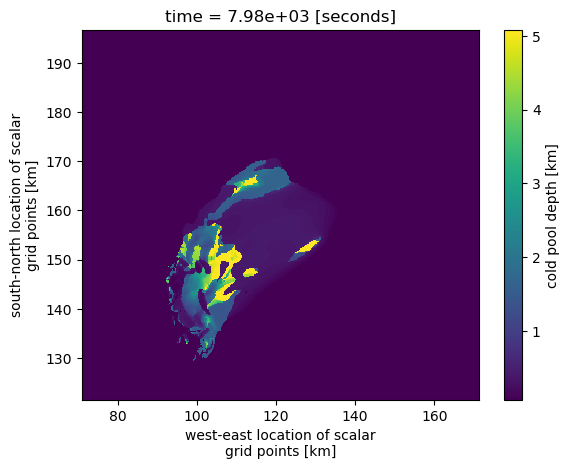

In [15]:
file = '/storm/topping/cold_pools/runs/2500_core/mm/derived_vars/derived_vars_000090.zarr'
ds = xr.open_zarr(
        file,
        zarr_format=3,
        consolidated=False,
        decode_timedelta=False
    )
cpd = ds['cp_depth']
cpd.plot()

In [16]:
ds2 = xr.open_dataset(exp_dir/'dm/derived_vars/derived_vars_000100.zarr')

/tmp/ipykernel_355624/1234529787.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds2 = xr.open_dataset(exp_dir/'dm/derived_vars/derived_vars_000100.zarr')


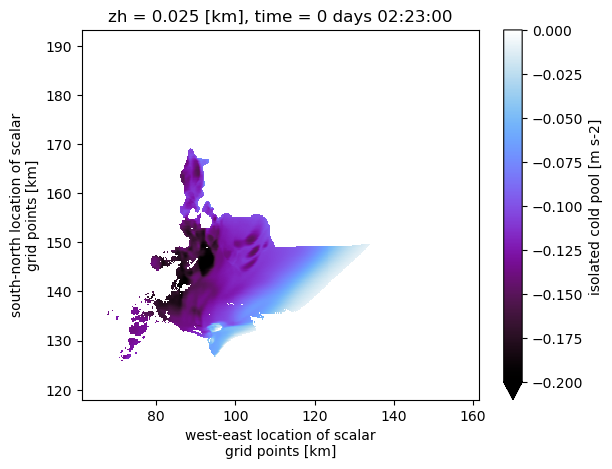

In [17]:
cp = ds2['cp_clean'].isel(time=0, zh=0)
norm = colors.Normalize(-0.2,0)
cp.where(cp <= -0.01).plot(cmap=cmr.voltage, norm=norm)

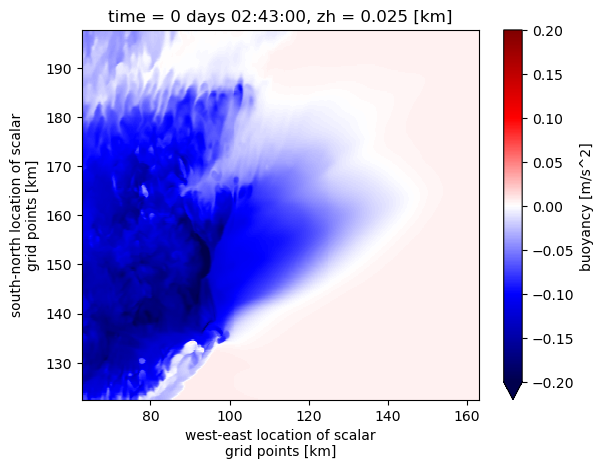

In [13]:
norm = colors.Normalize(-0.2,0.2)
cp = ds2['buoyancy'].isel(time=0, zh=0).plot(cmap='seismic', norm=norm)

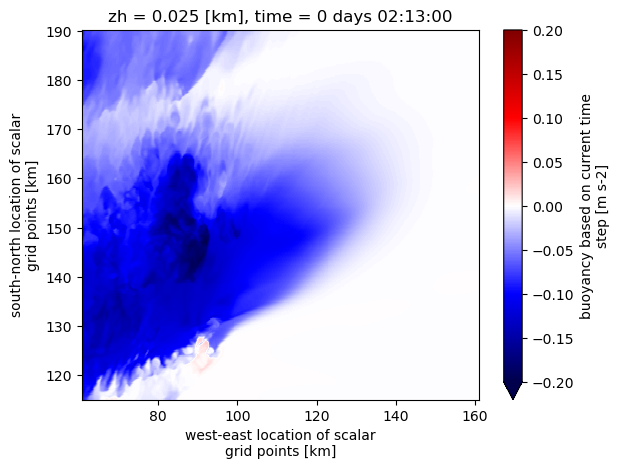

In [9]:
norm = colors.Normalize(-0.2,0.2)
ds2['b2'].isel(time=0, zh=0).plot(cmap='seismic', norm=norm)